# 🐍 Неделя 7. Общий семинар.

**Сегодня в программе:**
1. Типы данных и базовые объекты.
2. Математические операции с векторами.
3. Математические операции с матрицами.
4. Операции с изменением формы объектов.

Использовать будем Python и только библиотеку NumPy!

[*Ссылка на документацию*](https://numpy.org/).


In [1]:
import time
import numpy as np

*Прежде чем мы начнём...*

In [2]:
size_of_vec = 30000

def python():
    start = time.time()
    X = range(size_of_vec)
    Y = range(size_of_vec)
    Z = [X[i] + Y[i] for i in range(len(X))]
    return time.time() - start

def numpy():
    start = time.time()
    X = np.arange(size_of_vec)
    Y = np.arange(size_of_vec)
    Z = X + Y
    return time.time() - start

print("Numpy is in this example {} times faster!".format(python()/numpy()) )

Numpy is in this example 80.99618320610686 times faster!


## 🟢 1. Создание базовых объектов

Базовый объект NumPy - многомерный массив `np.array`, в рамках него можно задать и вектор, и матрицу, и тензор. Важные особенности numpy-массивов:
 * индексация всегда начинается с нуля, ~но можно обращаться к элементам по отрицательным индексам с конца~
 * казалось бы, может в себе содержать элементы разных типов, но на самом деле они автоматически будут приведены к одному типу
 * NumPy использует компактное представление данных в памяти и низкоуровневые оптимизированные операции, поэтому он работает гораздо быстрее обычных питоновских `list` и циклов `for`.

 А так, остаётся прежним принцип-синтаксис работы с методами (сначала создаём переменную-объект, а затем применяем к ней различные методы через точку).

Рассмотрим **примеры кода для создания базовых объектов линейной алгебры вручную, а также их характеристики** *(некоторые аттрибуты класса numpy-массива):*

In [3]:
# создадим несколько векторов из явного набора элементов
a = np.array([1, 2, 3])
b = np.array([1, 2, 3, 4.0])
c = np.array([1, 2, 3, 4.0, '5'])

# питоновская встроенная функция type показывает тип объекта (класс)
# .dtype - метод numpy-массивов, показывает тип его элементов
print(type(a),  a.dtype, a)
print(type(b),  b.dtype, b)
print(type(c),  c.dtype, c)

<class 'numpy.ndarray'> int64 [1 2 3]
<class 'numpy.ndarray'> float64 [1. 2. 3. 4.]
<class 'numpy.ndarray'> <U32 ['1' '2' '3' '4.0' '5']


In [4]:
# пример создания матрицы
A = np.array([[1, 2, 3], [3, 4, 5]])
print(type(A),  A.dtype)
A

<class 'numpy.ndarray'> int64


array([[1, 2, 3],
       [3, 4, 5]])

In [5]:
# никто не запрещает создать тензор
TT = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
print(type(TT),  TT.dtype)
TT

<class 'numpy.ndarray'> int64


array([[[1, 2],
        [3, 4]],

       [[5, 6],
        [7, 8]]])

In [6]:
# ndim покажет количество измерений массива (число осей)
# это не математическая размерность пространства из линала!
print(a.ndim)
print(A.ndim)
print(TT.ndim)

1
2
3


In [7]:
# shape - форму (кол-во элементов по каждой "оси")
print(a.shape, A.shape, TT.shape)

(3,) (2, 3) (2, 2, 2)


In [8]:
# size - суммарное кол-во элементов в объекте
print(a.size, A.size, TT.size)

3 6 8


Можно создавать объекты **автоматически с заданным "наполнением"**, например:
* массивы из нулей, единиц и других одинаковых чисел
* единичные матрицы
* случайные наборы чисел

**Важно:** в большинстве рассматриваемых далее функциях можно через параметр `shape=(...)` указывать форму объекта.

In [9]:
# матрица 3x3 из нулей
np.zeros(shape=(3, 3))

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [10]:
# вектор 1x3 из единиц
np.ones(shape=(3,))

array([1., 1., 1.])

In [11]:
# матрица заданного размера, заполенная -5
np.full((2, 2), -5)

array([[-5, -5],
       [-5, -5]])

In [12]:
# создание единичной матрицы
# PS: т.к. она может быть только квадратной,
# то достаточно указать в аргументе одно число:)
np.eye(5)

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

In [13]:
# рандомная матрица с числами от 0 до 1 заданного размера
np.random.random((5, 3))

array([[0.12592644, 0.8953814 , 0.89940808],
       [0.06248301, 0.05229529, 0.62314145],
       [0.29846597, 0.04750339, 0.44671902],
       [0.49538797, 0.89518489, 0.67665591],
       [0.37498001, 0.17882492, 0.80816479]])

In [14]:
# рандомная матрица с числами в диапазоне от 10 до 100
np.random.randint(10, 100, size=(2, 3))

array([[47, 21, 35],
       [27, 56, 60]])

Можно также создавать **последовательности, сгенерированные по определённым правилам**:

In [15]:
# генерация последовательностей чисел ОТ и ДО с заданным шагом
print(np.arange(0, 2, step=0.2))
print(np.arange(1, 10, step=2))
print(np.arange(5, -5, step=-2))

[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8]
[1 3 5 7 9]
[ 5  3  1 -1 -3]


In [16]:
# обратная задача: говорим сколько точек и в каком диапазоне
# хотим сгенерировать, шаг рассчитывается автоматически
print(np.linspace(0, 10, num=5))
print(np.linspace(-2, 2, num=8))

[ 0.   2.5  5.   7.5 10. ]
[-2.         -1.42857143 -0.85714286 -0.28571429  0.28571429  0.85714286
  1.42857143  2.        ]


## 🟢 2. Математические операции с векторами

В Numpy реализовано огромное множество как простейших, так и более сложных математических функций. Если под рукой нет инженерного калькулятора -- наверняка эта функция есть в Numpy 🙃

Более того, Numpy умеет делать расчёт как для одного числа, так и для массива чисел (вектора).

**Простейшие вычисления:**

In [17]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print(a + b)   # Сложение: [5 7 9]
print(np.add(a, b))

print(a - b)   # Вычитание: [-3 -3 -3]
print(np.subtract(a, b))

print(a * b)   # Поэлементное умножение: [4 10 18]
print(np.multiply(a, b))

print(a / b)   # Поэлементное деление: [0.25 0.4  0.5]
print(np.divide(a, b))

print(a * 5)  # Умножение на скаляд: [5 10 15]

print(a ** 2)  # Возведение в квадрат: [1 4 9]
print(np.power(a, 2))

print(np.sqrt(a))  # Квадратный корень: [1. 1.414 1.732]

[5 7 9]
[5 7 9]
[-3 -3 -3]
[-3 -3 -3]
[ 4 10 18]
[ 4 10 18]
[0.25 0.4  0.5 ]
[0.25 0.4  0.5 ]
[ 5 10 15]
[1 4 9]
[1 4 9]
[1.         1.41421356 1.73205081]


**Операции округления:**

In [18]:
x = np.array([1.56, -2.34, 3.78])

print(np.round(x, 1))   # Округление до одного знака: [ 1.6 -2.3  3.8]
print(np.floor(x))      # Округление вниз: [ 1. -3.  3.]
print(np.ceil(x))       # Округление вверх: [ 2. -2.  4.]
print(np.abs(x))        # Модуль: [1.56 2.34 3.78]

[ 1.6 -2.3  3.8]
[ 1. -3.  3.]
[ 2. -2.  4.]
[1.56 2.34 3.78]


**Тригонометрические операции:**

In [19]:
angles = np.array([0, np.pi / 2, np.pi])

print(np.sin(angles))  # [0. 1. 0.]
print(np.cos(angles))  # [ 1.  0. -1.]
print(np.tan(angles))  # [ 0.  1.634e+16  0.]  (tan(pi/2) → бесконечность)

[0.0000000e+00 1.0000000e+00 1.2246468e-16]
[ 1.000000e+00  6.123234e-17 -1.000000e+00]
[ 0.00000000e+00  1.63312394e+16 -1.22464680e-16]


In [20]:
x = np.linspace(0, 2 * np.pi, 10)
f = np.sin(x)
f

array([ 0.00000000e+00,  6.42787610e-01,  9.84807753e-01,  8.66025404e-01,
        3.42020143e-01, -3.42020143e-01, -8.66025404e-01, -9.84807753e-01,
       -6.42787610e-01, -2.44929360e-16])

**Логарифмы и экспоненты:**

In [21]:
values = np.array([1, 2, 10])

print(np.exp(values))   # [2.718 7.389 22026.465] (e^x)
print(np.log(values))   # [0. 0.693 2.302] (натуральный логарифм)
print(np.log10(values)) # [0. 0.301 1.] (десятичный логарифм)

[2.71828183e+00 7.38905610e+00 2.20264658e+04]
[0.         0.69314718 2.30258509]
[0.      0.30103 1.     ]


**Работа с массивами чисел:**

In [22]:
arr = np.array([1, 2, 3, 4, 5])

print(np.sum(arr))   # Сумма: 15
print(np.prod(arr))  # Произведение: 120
print(np.mean(arr))  # Среднее значение: 3.0
print(np.var(arr))   # Дисперсия: 2.0
print(np.std(arr))   # Среднеквадратичное отклонение: 1.414
print(np.min(arr))   # Минимум: 1
print(np.max(arr))   # Максимум: 5
print(np.unique([2, 2, 5, 5]))  # Уникальные значения: [2 5]

15
120
3.0
2.0
1.4142135623730951
1
5
[2 5]


## 🟢 3. Математические операции с матрицами

Внимание! Все операции для векторов работают и для матриц - и важно учесть, что и применяться они будут точно так же - поэлементно (для суммы и вычитания это нормально, а умножение получится не настоящим "матричным").

В этом разделе рассмотрим более хитрые операции линейной алгебры непосредственно для матриц (включая вектор-строки и вектор-столбцы).

In [23]:
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
print("Матрица A:\n", A)

Матрица A:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]


**Транспонирование:**

In [24]:
A_T = A.T # аналогичный результат от np.transpose(A)
print("Транспонированная матрица A:\n", A_T)

Транспонированная матрица A:
 [[1 4 7]
 [2 5 8]
 [3 6 9]]


**Поэлементные операции с матрицами (из старого):**

In [25]:
B = np.array([[9, 8, 7],
              [6, 5, 4],
              [3, 2, 1]])
print("Сумма:\n", A + B)  # Поэлементное сложение
print("Разность:\n", A - B)  # Поэлементное вычитание
print("Поэлементное умножение:\n", A * B)  # НЕ матричное умножение!

Сумма:
 [[10 10 10]
 [10 10 10]
 [10 10 10]]
Разность:
 [[-8 -6 -4]
 [-2  0  2]
 [ 4  6  8]]
Поэлементное умножение:
 [[ 9 16 21]
 [24 25 24]
 [21 16  9]]


**Матричное умножение:**

In [26]:
C = np.array([[1, 2],
              [3, 4],
              [5, 6]])
result = A @ C  # Матричное умножение (эквивалентно np.dot(A, C))
print("Результат A @ C:\n", result)

Результат A @ C:
 [[ 22  28]
 [ 49  64]
 [ 76 100]]


**Определитель матрицы:**

In [27]:
A_square = np.array([[2, 1],
                     [5, 3]])
det_A = np.linalg.det(A_square)
print("Определитель матрицы A_square:", det_A)

Определитель матрицы A_square: 1.0000000000000009


**Обратная матрица:**

In [28]:
inv_A = np.linalg.inv(A_square)
print("Обратная матрица A_square:\n", inv_A)

Обратная матрица A_square:
 [[ 3. -1.]
 [-5.  2.]]


**Ранг матрицы:**

In [29]:
rank_A = np.linalg.matrix_rank(A)
print("Ранг матрицы A:", rank_A)

Ранг матрицы A: 2


**Норма вектора и матрицы:**

In [30]:
v = np.array([3, 4])  # Вектор
print("L2-норма вектора:", np.linalg.norm(v))  # Евклидова норма (длина вектора)

L2-норма вектора: 5.0


Numpy умеет легко и просто решать **системы линейных уравнений** - достаточно задать матрицу системы и столбец свободных коэффициентов.

In [31]:
A_sys = np.array([[2, 1],
                  [5, 3]])  # Коэффициенты уравнений

b = np.array([1, 4])  # Правая часть

solution = np.linalg.solve(A_sys, b)
print("Решение системы уравнений (x, y):", solution)

Решение системы уравнений (x, y): [-1.  3.]


## 🟢 4. Операции с изменением формы объектов

И последний раздел - про изменения, связанные с формой. Они редко относятся к математике, но могут пригодиться при формировании датасетов для анализа, обучения ML-моделей и т.п.

**Изменение формы массива (`reshape`)**

Позволяет изменить размерность массива без изменения данных.

*PS: `reshape` не всегда бывает возможным; нужно, чтобы кол-во элементов в массиве до и после были одинаковыми.*

In [32]:
arr = np.arange(12)  # массив [0, 1, 2, ..., 11]
print(arr.shape)
print(arr)

reshaped = arr.reshape(3, 4)  # Делаем из него 3x4
print('\n', reshaped.shape)
print(reshaped)

(12,)
[ 0  1  2  3  4  5  6  7  8  9 10 11]

 (3, 4)
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [33]:
arr.reshape((1, 12))

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]])

**Объединение массивов (`concatenate`)**

Можно объединять массивы вдоль разных осей.

In [34]:
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6]])

# По вертикали (добавляем строки)
vertical_concat = np.concatenate((a, b), axis=0)
print(vertical_concat)

# По горизонтали (добавляем столбцы)
horizontal_concat = np.concatenate((a, b.T), axis=1)
print(horizontal_concat)

[[1 2]
 [3 4]
 [5 6]]
[[1 2 5]
 [3 4 6]]


**Фильтрация элементов (np.where)**

Позволяет выбрать элементы, соответствующие условию.

In [35]:
arr = np.array([10, 25, 8, 12, 30])
filtered = arr[np.where(arr > 15)]  # Оставляем только элементы > 15
print(filtered)

[25 30]


In [36]:
arr[0], arr[1]

(10, 25)

**Основы срезов (`:`)**

В NumPy можно обращаться к элементам массива по индексам, а можно "вырезать" части массива с помощью срезов (slices).

*Тут теории побольше, разберём всё по порядку...*

**Базовый синтаксис:**

```
array[start:stop:step]
```

* `start` – индекс начала среза (включительно, по умолчанию 0)
* `stop` – индекс конца среза (не включается, по умолчанию конец массива)
* `step` – шаг, с которым выбираются элементы (по умолчанию 1)

Можно указать как все три аргумента при срезе, так и пропустить какие-либо из них. Если пропускаете шаг `step` - то можно просто его не писать; а если пропускаете начало `start` или конец `stop` - то важно прописать "пустые" двоеточия.

*Вот несколько примеров:*

In [37]:
arr = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
print(arr[1:4])  # [1, 2, 3] (элементы с индекса 1 до 3)
print(arr[1:6:2])  # [1, 3, 5] (элементы с индекса 1 до 6 с шагом 2)
print(arr[:5])   # [0 1 2 3 4]  – от начала до 5-го элемента (не включается)
print(arr[3:])   # [3 4 5 6 7 8 9]  – с 3-го элемента до конца
print(arr[::2])  # [0 2 4 6 8] – каждый второй элемент

[1 2 3]
[1 3 5]
[0 1 2 3 4]
[3 4 5 6 7 8 9]
[0 2 4 6 8]


Любопытно, что в Numpy индексы могут быть и отрицательными - это значит, что элементы будут браться не с начала, а с конца.

*Вот несколько примеров:*

In [38]:
print(arr[-1])   # Выбираем последний элемент
print(arr[-2])   # Выбираем предпоследний элемент
print(arr[-3:])  # Срез последних трёх элементов
print(arr[:-2])  # Срез всех элементов, кроме последних двух
print(arr[::-1]) # Разворот массива

9
8
[7 8 9]
[0 1 2 3 4 5 6 7]
[9 8 7 6 5 4 3 2 1 0]


Абсолютно аналогичные правила работают и для срезов матриц, просто указываем отдельные "правила" для каждой оси в квадратных скобках через запятую:

```
array[start_row:end_row, start_col:end_col]
```

In [39]:
arr = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])

print(arr[:2, :3])  # Берём первые 2 строки и первые 3 столбца
# [[1  2  3]
#  [5  6  7]]

print(arr[1:, 2:])  # С 1-й строки до конца, со 2-го столбца до конца
# [[ 7  8]
#  [11 12]]

[[1 2 3]
 [5 6 7]]
[[ 7  8]
 [11 12]]


**На последок...**

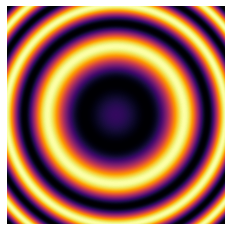

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import display, clear_output

# Размер сетки
m, n = 200, 200

# Создаём координатную сетку
x = np.linspace(-1, 1, m)
y = np.linspace(-1, 1, n)
X, Y = np.meshgrid(x, y)

# Основной цикл анимации
for t in range(30):
    Z = np.sin(10 * (X**2 + Y**2) - t * 0.3)  # Волнообразный эффект

    plt.imshow(Z, cmap='inferno', interpolation='bilinear')
    plt.axis('off')  # Убираем оси для красоты

    display(plt.gcf())  # Отображаем изображение
    clear_output(wait=True)  # Очищаем предыдущее изображение

# 🌟 До скорых встреч!